In [13]:
import torch
import mhnlib.utils as mhn_utils
from math import log, sqrt
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from typing import Optional, Tuple, Union

## 1-step hierarchical matrices

### Vary $M$ block size

In [14]:
torch.manual_seed(1101252)
K = 256
N = 32
S = 100
Ms = 2**torch.arange(0, torch.log2(torch.tensor(S)).int()+1)
rho0 = 0.2
rho1 = 0.6
patterns_per_M = {}
for M in Ms:
    global_patterns = sqrt(rho0)*torch.randn(S, N)/sqrt(N)
    block_patterns = sqrt(rho1-rho0)*torch.randn(S, M, N)/sqrt(N)
    local_patterns = sqrt(1-rho1)*torch.randn(S,K, N)/sqrt(N)
    patterns = global_patterns[:,None, :] + torch.repeat_interleave(block_patterns, K//M, dim=1) + local_patterns
    patterns_per_M[M.item()] = patterns
    break

### Annealing

In [15]:
torch.manual_seed(1101252)
N_betas_annealing = 100
N_ic_annealing = 300
x_ic = torch.randn(N_ic_annealing, N)/sqrt(N)
betas_annealing = torch.logspace(-1, 2, steps=N_betas_annealing)
logit_noise_std = 0.1
num_iterations = 1000
x_fps_annealing, prob_fps_annealing = mhn_utils.deterministic_dynamics_annealing(
    patterns=patterns.to('mps'),
    biases=torch.zeros(K).to('mps'),
    betas=betas_annealing.to('mps'),
    x0=x_ic.to('mps'),
    logit_noise_std=logit_noise_std,
    num_iterations=num_iterations,
    return_probs=True,
    verbose=True)
x_fps_annealing = x_fps_annealing.cpu()
prob_fps_annealing = prob_fps_annealing.cpu()
entropies_annealing = mhn_utils.get_entropy(prob_fps_annealing)

Annealing:   0%|          | 0/100 [00:00<?, ?it/s]

### Quenching

In [16]:
torch.manual_seed(1101252)
N_betas_quenching = 100
N_ic_quenching = 300
x_ic = torch.randn(N_ic_quenching, N)/sqrt(N)
betas_quenching = torch.logspace(-1, 2, steps=N_betas_quenching)
num_iterations = 1000
x_fps_quenching, prob_fps_quenching = mhn_utils.deterministic_fixed_points(
    patterns=patterns.to('mps'),
    biases=torch.zeros(K).to('mps'),
    betas=betas_quenching.to('mps'),
    x0=x_ic.to('mps'),
    num_iterations=num_iterations,
    return_probs=True,
    verbose=True)
x_fps_quenching = x_fps_quenching.cpu()
prob_fps_quenching = prob_fps_quenching.cpu()
entropies_quenching = mhn_utils.get_entropy(prob_fps_quenching)

Computing fixed points:   0%|          | 0/1000 [00:00<?, ?it/s]

### Stochastic

In [26]:
torch.manual_seed(1101252)
N_betas_stochastic = 100
N_ic_stochastic = 10
x_ic = torch.randn(N_ic_stochastic, N)/sqrt(N)
betas_stochastic = torch.logspace(-1, 2, steps=N_betas_stochastic)
num_iterations = 5000
x_fps_stochastic, prob_fps_stochastic = mhn_utils.stochastic_dynamics(
    patterns=patterns.to('mps'),
    biases=torch.zeros(K).to('mps'),
    betas=betas_stochastic.to('mps'),
    temp0 = 10.0,
    use_beta_as_inverse_temp=False,
    x0=x_ic.to('mps'),
    num_iterations=num_iterations,
    dt = 0.1,
    return_probs=True,
    verbose=True)
x_fps_stochastic = x_fps_stochastic.cpu()
prob_fps_stochastic = prob_fps_stochastic.cpu()
entropies_stochastic = mhn_utils.get_entropy(prob_fps_stochastic)

Computing fixed points:   0%|          | 0/5000 [00:00<?, ?it/s]

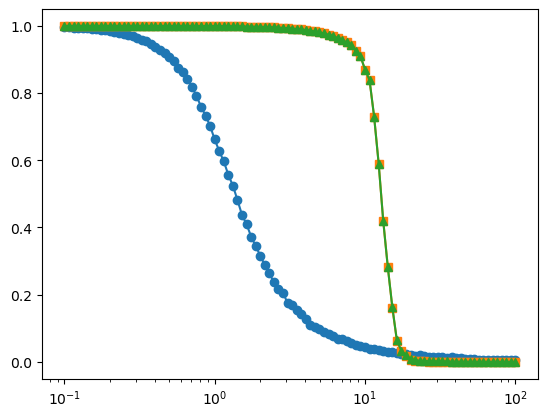

In [28]:
plt.plot(betas_stochastic, entropies_stochastic.mean(dim=(1,2))/log(K), label='Stochastic', marker='o')
plt.plot(betas_annealing, entropies_annealing.mean(dim=(1,2))/log(K), label='Annealing', marker='s')
plt.plot(betas_quenching, entropies_quenching.mean(dim=(1,2))/log(K), label='Quenching', marker='^')
plt.xscale('log')
plt.show()